In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
%matplotlib inline
from IPython.display import clear_output

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

data_folder = "drive/MyDrive/mestrado_final_files/data/"
models_folder = "drive/MyDrive/mestrado_final_files/models/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_folder = "G:\Meu Drive\mestrado_final_files\models\\"

In [2]:
pd.set_option("display.expand_frame_repr", False)

In [3]:

df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
[['GAME_ID', 'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'HOME_TEAM', 'AWAY_TEAM', 'GAME_DATE', 'HOME_PTS', 'AWAY_PTS']]

columns_boxscore = ["home_FGM", "away_FGM", "home_FGA", "away_FGA", "home_FGP", "away_FGP", 
                    "home_3FGM", "away_3FGM", "home_3FGA", "away_3FGA", "home_3FGP", "away_3FGP", 
                    "home_FTM", "away_FTM", "home_FTA", "away_FTA", "home_FTP", "away_FTP", 
                    "home_RebOff", "away_RebOff", "home_RebDef", "away_RebDef", "home_RebTot", 
                    "away_RebTot", "home_AST", "away_AST", "home_STL", "away_STL", "home_BLK", 
                    "away_BLK", "home_TO", "away_TO", "home_FP", "away_FP", "home_points", 
                    "away_points", "home_PMP", "away_PMP", "home_outcome", 'away_outcome']

df_boxscore = pd.read_csv(data_folder + 'boxscore_moving_average20.txt', sep = ';')\
.set_index("game_id")\
[columns_boxscore]

In [4]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [5]:
VOCAB_SIZE = 601
TIME_SIZE = 301
BATCH_SIZE = 8192
TRAIN_STEPS = 50001
run_models = 1

In [6]:
full_covariables = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
                    'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds', 
                    'ind_last_10_seconds', 'lead', 'ball_possession', 'home_FGM', 'away_FGM', 
                    'home_FGA', 'away_FGA', 'home_FGP', 'away_FGP', 'home_3FGM', 'away_3FGM', 
                    'home_3FGA', 'away_3FGA', 'home_3FGP', 'away_3FGP', 'home_FTM', 'away_FTM', 
                    'home_FTA', 'away_FTA', 'home_FTP', 'away_FTP', 'home_RebOff', 'away_RebOff', 
                    'home_RebDef', 'away_RebDef', 'home_RebTot', 'away_RebTot', 'home_AST', 'away_AST', 
                    'home_STL', 'away_STL', 'home_BLK', 'away_BLK', 'home_TO', 'away_TO', 'home_FP', 
                    'away_FP', 'home_points', 'away_points', 'home_PMP', 'away_PMP', 'home_outcome', 
                    'away_outcome', 'home_away_dif', 'playoff_game']

covariables_model = ['period1', 'period2', 'period3', 'period4', 'period_overtime', 'time', 
                     'limhfouls', 'limvfouls', 'dif', 'ind_last_minute', 'ind_last_20_seconds',
                     'ind_last_10_seconds', 'lead', 'ball_possession']

index_covariables = [i for i, var in enumerate(full_covariables) if var in covariables_model]

In [7]:
%run 06_functions_simulations.ipynb

In [10]:
CONTEXT_SIZE = 5
EMBEDDING_LAYER_SIZE = 16

In [11]:
model_file = models_folder + 'model_token_simplevars_context5_emb16_hiddenlayers3_numneurons100_multiplicador1_parameters.pth'
#model_file = models_folder + 'model_token_simplevars_context5_emb64_hiddenlayers3_numneurons100_multiplicador3_parameters.pth'

num_ngram_model = NGramModel_ExtraInfo(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE, 
                                       numerical_input_dim = len(index_covariables), num_hidden_neurons = [100, 100, 100], 
                                       num_layers = 3, activation = nn.ReLU)

num_ngram_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
num_ngram_model.eval()

NGramModel_ExtraInfo(
  (embedding): Embedding(601, 16)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=94, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=100, out_features=601, bias=True)
  )
)

In [12]:
model_file = models_folder + 'model_time_simplevars_context5_emb16_hiddenlayers3_numneurons100_multiplicador1_parameters.pth'

simple_time_model = SpentTimeModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, time_size = TIME_SIZE,
                                   embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(covariables_model),
                                   num_hidden_neurons = [100, 100, 100], num_layers = 3, activation_function = nn.GELU)

simple_time_model.load_state_dict(torch.load(model_file, weights_only = True, map_location = torch.device('cpu')))
simple_time_model.eval()


SpentTimeModel(
  (embedding): Embedding(601, 16)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=94, out_features=100, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=100, out_features=301, bias=True)
  )
)

In [29]:
xdf, df_points = generate_game_plays(token_model = num_ngram_model, time_model = simple_time_model, num_simulations = 1000,
                                     token_vector =  [0] * 5, numerical_vector = [0.] * 14)


Generated plays for period: 1. Here some metrics:
              count   mean   std   min    25%   50%   75%   max
home_points  1000.0  29.29  5.83   6.0  25.75  29.0  33.0  49.0
away_points  1000.0  29.35  6.04  14.0  25.00  29.0  33.0  51.0
outcome   away   home    tie
size     0.477  0.471  0.052
Generated plays for period: 2. Here some metrics:
              count   mean   std   min   25%   50%   75%   max
home_points  1000.0  58.70  8.39  31.0  53.0  59.0  64.0  90.0
away_points  1000.0  59.26  8.20  36.0  54.0  59.0  65.0  81.0
outcome   away   home    tie
size     0.498  0.474  0.028
Generated plays for period: 3. Here some metrics:
              count   mean    std   min    25%   50%   75%    max
home_points  1000.0  87.70  10.59  45.0  80.00  88.0  94.0  118.0
away_points  1000.0  88.35   9.97  62.0  81.75  88.0  95.0  119.0
outcome   away   home    tie
size     0.498  0.486  0.016
Generated plays for period: 4. Here some metrics:
              count    mean    std   min    25%

In [34]:
list_points = []
for p in [1, 2, 3, 4]:
    for t in [7200, 6600, 6000, 5400, 4800, 4200, 3600, 3000, 2400, 1800, 1200, 600, 300, 150, 0]:
        print(p, t)
        df_ = xdf\
        .query("period == @p & remaining_time >= @t")\
        .groupby("simulation")\
        .apply(lambda df: df.iloc[[-1]], include_groups = False)\
        [["home_points", "away_points"]].describe().T.reset_index()\
        .assign(period = p, ref_remaining_time = t)
        list_points.append(df_)
        clear_output(wait = True)

4 0


In [ ]:
real_data = pd.DataFrame(
    {"ref_remaining_time": [7200, 6600, 6000, 5400, 4800, 4200, 3600, 3000, 2400, 1800, 1200, 600, 200, 100, 0],
     "away_points_1": [0.000000, 1.706131, 2.261452, 2.426357, 2.387068, 2.432699, 2.367336, 2.356589, 2.390240, 2.374912, 2.334038, 2.331395, 1.694327, 0.236082, 0.600951],
     "away_points_2": [0.001233, 1.822939, 2.283650, 2.295807, 2.294397, 2.291402, 2.288231, 2.341790, 2.350775, 2.403982, 2.431290, 2.480444, 1.774841, 0.255285, 0.656624],
     "away_points_3": [0.004405, 1.821705, 2.317653, 2.430937, 2.338795, 2.330867, 2.364870, 2.298978, 2.379316, 2.342495, 2.323115, 2.378259, 1.670014, 0.238020, 0.628612],
     "away_points_4": [0.001586, 1.782065, 2.227977, 2.218111, 2.207364, 2.196265, 2.183756, 2.202255, 2.164200, 2.194327, 2.177942, 2.463178, 1.893058, 0.524313, 0.549154],
     "home_points_1": [0.000000, 1.784179, 2.377202, 2.435518, 2.512861, 2.490310, 2.390416, 2.393587, 2.402220, 2.396934, 2.330162, 2.404334, 1.760747, 0.229035, 0.659443],
     "home_points_2": [0.000881, 1.869098, 2.325758, 2.380726, 2.334390, 2.321353, 2.312192, 2.350599, 2.397463, 2.465997, 2.464235, 2.537879, 1.851832, 0.229563, 0.699084],
     "home_points_3": [0.003876, 1.867865, 2.293340, 2.420366, 2.398168, 2.459831, 2.402925, 2.389006, 2.361875, 2.394292, 2.326462, 2.356589, 1.691156, 0.261099, 0.661381],
     "home_points_4": [0.002467, 1.826815, 2.227273, 2.267266, 2.234672, 2.216173, 2.214940, 2.239782, 2.226568, 2.227449, 2.234144, 2.450317, 1.889887, 0.523608, 0.528013]
     })\
.set_index("ref_remaining_time")

In [40]:
df0 = pd.concat(list_points)\
.sort_values(["index", "period", "ref_remaining_time"], ascending = [False, True, False])\
.assign(lag = lambda df: df.groupby("index")["mean"].shift(1).fillna(0))\
.assign(pts = lambda df: df["mean"] - df["lag"])\
.pivot_table(index = ["ref_remaining_time"], columns = ["index", "period"], values = "pts")\
.reset_index()\
.sort_values(["ref_remaining_time"], ascending = [False])\
.reset_index(drop = True)\
.set_index("ref_remaining_time")

df0.columns = ['away_points_1', 'away_points_2', 'away_points_3', 'away_points_4', 'home_points_1', 'home_points_2', 'home_points_3', 'home_points_4']


<Axes: xlabel='ref_remaining_time'>

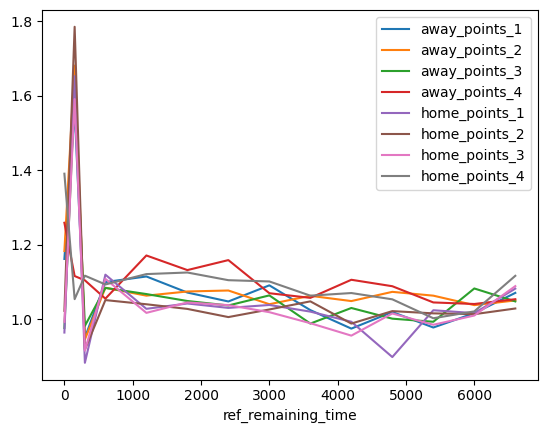

In [46]:
(df0.query("ref_remaining_time < 7200") / real_data.query("ref_remaining_time < 7200")).plot()

In [18]:
xdf\
.groupby(["simulation", "period"], as_index = False, dropna = False).size()\
.groupby(["period"], as_index = False, dropna = False)["size"].describe()

,period,count,mean,std,min,25%,50%,75%,max
0,1.0,1000.0,97.434000,10.084708,73.0,90.00,96.0,104.0,130.0
1,2.0,1000.0,99.849000,10.552040,69.0,93.00,98.5,106.0,146.0
2,3.0,1000.0,96.641000,9.780070,68.0,90.00,96.0,103.0,132.0
3,4.0,1000.0,101.478000,11.503645,68.0,94.00,100.0,109.0,147.0
4,5.0,38.0,44.473684,7.643180,30.0,38.75,44.5,49.0,62.0
5,6.0,1.0,39.000000,NaN,39.0,39.00,39.0,39.0,39.0


In [23]:
xdf\
.groupby(["simulation", "period"])\
.apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby('period')[["limhteam", 'limvteam']].describe()

limhteam                                                limvteam                                              
          count      mean       std   min  25%  50%   75%  max    count      mean       std   min  25%  50%  75%  max
period                                                                                                               
1.0      1000.0 -2.154000  1.995562 -11.0 -3.0 -2.0 -1.00  1.0   1000.0 -1.878000  1.987729 -11.0 -3.0 -2.0  0.0  1.0
2.0      1000.0 -2.352000  2.024400 -11.0 -4.0 -2.0 -1.00  1.0   1000.0 -2.494000  2.171792 -12.0 -4.0 -2.0 -1.0  1.0
3.0      1000.0 -2.200000  2.017441 -11.0 -3.0 -2.0 -1.00  1.0   1000.0 -2.154000  2.001072 -13.0 -3.0 -2.0 -1.0  1.0
4.0      1000.0 -2.867000  2.172563 -11.0 -4.0 -3.0 -1.00  1.0   1000.0 -3.052000  2.334255 -13.0 -5.0 -3.0 -1.0  1.0
5.0        38.0 -0.421053  1.177069  -3.0 -1.0  0.0  0.75  1.0     38.0 -0.947368  1.469462  -5.0 -1.0 -1.0  0.0  1.0
6.0         1.0  1.000000       NaN   1.0  1.0  1.0  1.00  1.0      1.0  0.000000       NaN   0.0  0.0  0.0  0.0  0.0

In [24]:
xdf\
.groupby(["simulation", "period"])\
.apply(lambda df: df.iloc[[-1]], include_groups = False)\
.groupby('period')[["home_points", 'away_points']].describe()

home_points                                                           away_points                                                           
             count        mean        std    min    25%    50%    75%    max       count        mean        std    min     25%    50%    75%    max
period                                                                                                                                             
1.0         1000.0   29.427000   6.039631   13.0   25.0   29.0   34.0   51.0      1000.0   29.631000   6.162371   12.0   25.00   29.0   34.0   48.0
2.0         1000.0   58.969000   8.664936   30.0   53.0   58.0   65.0   87.0      1000.0   59.120000   8.364422   36.0   53.00   59.0   65.0   88.0
3.0         1000.0   87.951000  10.477040   58.0   81.0   88.0   95.0  122.0      1000.0   88.223000  10.323849   61.0   81.00   88.0   95.0  126.0
4.0         1000.0  117.442000  12.244369   80.0  109.0  117.0  126.0  162.0      1000.0  118.046000  11.933159   79.0  110.00  118.0  125.0  162.0
5.0           38.0  127.789474   9.759702  102.0  120.5  128.0  135.0  150.0        38.0  126.578947   9.744386  111.0  119.25  125.0  134.5  151.0
6.0            1.0  145.000000        NaN  145.0  145.0  145.0  145.0  145.0         1.0  141.000000        NaN  141.0  141.00  141.0  141.0  141.0

In [25]:
xdf\
.assign(ind_h = lambda df: df.groupby(["simulation", "period"])["home_points"].shift(1))\
.assign(ind_a = lambda df: df.groupby(["simulation", "period"])["away_points"].shift(1))\
.query("ind_h.notna() & ind_a.notna()")\
.assign(ind_h = lambda df: (df["home_points"] > df["ind_h"]).astype(int))\
.assign(ind_a = lambda df: (df["away_points"] > df["ind_a"]).astype(int))\
.groupby(["simulation", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                                     ind_a                                                  
         count       mean       std  min   25%   50%   75%   max   count       mean       std  min   25%   50%   75%   max
period                                                                                                                    
1.0     1000.0  14.423000  2.981436  6.0  12.0  14.0  16.0  26.0  1000.0  14.567000  3.048738  6.0  12.0  14.0  17.0  25.0
2.0     1000.0  14.788000  3.146897  6.0  13.0  15.0  17.0  25.0  1000.0  14.738000  3.186771  5.0  12.0  15.0  17.0  28.0
3.0     1000.0  14.326000  2.906918  6.0  12.0  14.0  16.0  23.0  1000.0  14.449000  3.018694  5.0  12.0  14.0  16.0  24.0
4.0     1000.0  14.971000  3.202876  7.0  13.0  15.0  17.0  27.0  1000.0  15.061000  3.225784  6.0  13.0  15.0  17.0  27.0
5.0       38.0   6.605263  2.137686  2.0   6.0   6.5   8.0  12.0    38.0   5.789474  2.055420  1.0   4.0   6.0   7.0  11.0
6.0        1.0   5.000000       NaN  5.0   5.0   5.0   5.0   5.0     1.0   3.000000       NaN  3.0   3.0   3.0   3.0   3.0

In [28]:
xdf\
.assign(play = lambda df: [integer_to_token[item] for item in df["token"]])\
.assign(ind_h = lambda df: df["play"].str.contains("4.._1\(5").astype("int"))\
.assign(ind_a = lambda df: df["play"].str.contains("5.._1\(5").astype("int"))\
.groupby(["simulation", "period"])[["ind_h", 'ind_a']].sum()\
.reset_index()\
.groupby("period")[["ind_h", "ind_a"]].describe()

ind_h                                             ind_a                                             
         count   mean       std  min  25%  50%  75%  max   count      mean       std  min  25%  50%  75%  max
period                                                                                                       
1.0     1000.0  2.658  1.604871  0.0  1.0  3.0  4.0  8.0  1000.0  2.646000  1.558561  0.0  1.0  2.0  4.0  9.0
2.0     1000.0  2.555  1.520292  0.0  1.0  2.0  3.0  9.0  1000.0  2.520000  1.457300  0.0  2.0  2.0  3.0  8.0
3.0     1000.0  2.533  1.465284  0.0  1.0  2.0  3.0  8.0  1000.0  2.424000  1.463682  0.0  1.0  2.0  3.0  9.0
4.0     1000.0  2.380  1.505944  0.0  1.0  2.0  3.0  8.0  1000.0  2.504000  1.514688  0.0  1.0  2.0  3.0  8.0
5.0       38.0  1.000  0.986394  0.0  0.0  1.0  1.0  4.0    38.0  1.342105  1.097326  0.0  1.0  1.0  2.0  4.0
6.0        1.0  0.000       NaN  0.0  0.0  0.0  0.0  0.0     1.0  0.000000       NaN  0.0  0.0  0.0  0.0  0.0